# Displacement Viewer

Clean, standalone notebook for inspecting per-marker displacement (px and mm) for any video.

**Workflow:**
1. Run **Section 1–3** once to set up helpers.
2. Run **Section 4** to see full graphs for the four 150-PWM videos.
3. Identify interesting time windows from the full graphs.
4. Use **Section 5** (fill in your time range + marker selection) to zoom in.

The `plot_displacement` function handles everything — tracking, displacement computation, dual-axis graph — for any video in `data/final/`.

## 1. Setup

In [21]:
import json
import sys
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data" / "top_recording").exists():
            return p
    raise FileNotFoundError("Cannot locate project root (expected data/top_recording)")


PROJECT_ROOT         = find_project_root(Path.cwd())
FINAL_DIR            = PROJECT_ROOT / "data" / "final"
VIEWER_TRACKING_DIR  = FINAL_DIR / "tracking_viewer"   # separate from marker_tracking.ipynb output
VIEWER_TRACKING_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(PROJECT_ROOT / "analysis"))
from core.marker_tracker import MarkerTracker

TOP_MM_PER_PX  = 0.1664
SIDE_MM_PER_PX = 0.1197

print(f"Project root: {PROJECT_ROOT}")
print(f"Tracking output: {VIEWER_TRACKING_DIR}")

Project root: c:\Users\goldw\Documents\gswt\ITB\TA252602\Software\AngioSim\software\testing\CardiacMotionTest
Tracking output: c:\Users\goldw\Documents\gswt\ITB\TA252602\Software\AngioSim\software\testing\CardiacMotionTest\data\final\tracking_viewer


## 2. Helpers — load setup, robust tracking, displacement

In [22]:
def load_setup(video_name: str):
    """Return (markers, rest_frame_index) from the setup JSON."""
    setup_path = FINAL_DIR / f"{video_name}_setup.json"
    if not setup_path.exists():
        raise FileNotFoundError(f"No setup file: {setup_path}")
    with open(setup_path) as f:
        d = json.load(f)
    return [tuple(m) for m in d["markers"]], d["rest_frame_index"]


def track_robust(video_path: Path, markers, rest_frame_index: int) -> pd.DataFrame:
    """
    Bidirectional LK tracking where a lost marker becomes NaN instead of
    aborting tracking for all other markers.
    """
    cap   = cv2.VideoCapture(str(video_path))
    fps   = cap.get(cv2.CAP_PROP_FPS) or 30.0
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    n     = len(markers)
    rows: dict = {}

    cap.set(cv2.CAP_PROP_POS_FRAMES, rest_frame_index)
    ok, rest_frame = cap.read()
    if not ok:
        raise RuntimeError(f"Cannot read rest frame {rest_frame_index}")
    rest_gray = cv2.cvtColor(rest_frame, cv2.COLOR_BGR2GRAY)
    rows[rest_frame_index] = (rest_frame_index / fps, list(markers))

    def _pass(frames_iter):
        points = np.array(markers, dtype=np.float32).reshape(-1, 1, 2)
        alive  = [True] * n
        prev   = rest_gray
        for idx, frame in frames_iter:
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            new_pts, status, _ = cv2.calcOpticalFlowPyrLK(
                prev, gray, points, None, **MarkerTracker.LK_PARAMS
            )
            prev = gray
            pos  = []
            for i in range(n):
                lost = (not alive[i]) or new_pts is None or status is None or status[i][0] != 1
                if lost:
                    if alive[i]:
                        print(f"    marker {i} lost at frame {idx}")
                    alive[i] = False
                    pos.append((np.nan, np.nan))
                else:
                    x, y = float(new_pts[i][0][0]), float(new_pts[i][0][1])
                    points[i][0] = [x, y]
                    pos.append((x, y))
            rows[idx] = (idx / fps, pos)
            if not any(alive):
                break

    def _fwd():
        idx = rest_frame_index + 1
        while idx < total:
            ok, f = cap.read()
            if not ok:
                return
            yield idx, f
            idx += 1

    _pass(_fwd())

    if rest_frame_index > 0:
        cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
        buf = []
        for i in range(rest_frame_index):
            ok, f = cap.read()
            if not ok:
                break
            buf.append((i, f))
        _pass(reversed(buf))

    cap.release()

    out = []
    for frame in sorted(rows):
        t, pos = rows[frame]
        row = {"frame": frame, "time_s": t}
        for i, (x, y) in enumerate(pos):
            row[f"m{i}_x_px"] = x
            row[f"m{i}_y_px"] = y
        out.append(row)
    return pd.DataFrame(out)


def get_displacement_df(video_name: str) -> tuple:
    """
    Always re-tracks the video and saves to VIEWER_TRACKING_DIR (overwriting any
    previous result). Computes per-marker displacement from rest.
    Returns (df_with_disp, markers).
    """
    markers, rest_idx = load_setup(video_name)
    csv_path  = VIEWER_TRACKING_DIR / f"{video_name}_positions.csv"
    mm_per_px = TOP_MM_PER_PX if video_name.startswith("top_") else SIDE_MM_PER_PX

    video_path = FINAL_DIR / f"{video_name}.mp4"
    print(f"[{video_name}] tracking...")
    pos_df = track_robust(video_path, markers, rest_idx)
    pos_df.to_csv(csv_path, index=False)
    print(f"  -> {len(pos_df)} frames saved to tracking_viewer/{csv_path.name}")

    df = pos_df.copy()
    for i, (rx, ry) in enumerate(markers):
        xc, yc = f"m{i}_x_px", f"m{i}_y_px"
        if xc in df.columns:
            disp_px = np.hypot(df[xc] - rx, df[yc] - ry)
            df[f"m{i}_disp_px"] = disp_px
            df[f"m{i}_disp_mm"] = disp_px * mm_per_px

    return df, markers


# Session cache for plot_combined — avoids re-tracking the same video multiple times.
# Re-running this cell clears the cache (forcing a fresh track on next plot_combined call).
_CACHE: dict = {}

print("Helpers loaded.")

Helpers loaded.


## 3. Plot function

In [23]:
def plot_displacement(
    video_name: str,
    markers: list = None,
    t_start: float = None,
    t_end:   float = None,
    save:    bool  = False,
) -> None:
    """
    Dual-axis (px left, mm right) displacement graph.

    Parameters
    ----------
    video_name : str
        Stem of the video in data/final/, e.g. 'top_with_acc_150'.
    markers : list[int] | None
        Marker indices to show, e.g. [1, 2, 3].  None = all valid markers.
    t_start, t_end : float | None
        Time window in seconds.  None = full recording.
    save : bool
        Save PNG next to the displacement folder.
    """
    df, setup_markers = get_displacement_df(video_name)

    # Determine which marker indices have any valid (non-NaN) data
    n = len(setup_markers)
    valid = [
        i for i in range(n)
        if f"m{i}_disp_px" in df.columns and df[f"m{i}_disp_px"].notna().any()
    ]
    if markers is not None:
        show = [i for i in markers if i in valid]
        missing = [i for i in markers if i not in valid]
        if missing:
            print(f"  Warning: markers {missing} have no valid data for {video_name} — skipped")
    else:
        show = valid

    if not show:
        print(f"No valid markers to plot for {video_name}.")
        return

    # Time filter
    mask = pd.Series([True] * len(df))
    if t_start is not None:
        mask &= df["time_s"] >= t_start
    if t_end is not None:
        mask &= df["time_s"] <= t_end
    data = df[mask]

    if data.empty:
        print(f"No data in time range [{t_start}, {t_end}] for {video_name}.")
        return

    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    fig, ax1 = plt.subplots(figsize=(13, 5))
    ax2 = ax1.twinx()

    for ci, i in enumerate(show):
        col_px = f"m{i}_disp_px"
        col_mm = f"m{i}_disp_mm"
        c = colors[ci % len(colors)]
        ax1.plot(data["time_s"], data[col_px], lw=1.4, color=c, label=f"m{i}")
        ax2.plot(data["time_s"], data[col_mm], lw=1.4, color=c, ls="--", alpha=0.7)

    ax1.set_xlabel("Time (s)", fontsize=11)
    ax1.set_ylabel("Displacement (px)",  fontsize=11)
    ax2.set_ylabel("Displacement (mm)",  fontsize=11)
    ax1.grid(alpha=0.3)

    t_label = ""
    if t_start is not None or t_end is not None:
        lo = f"{t_start:.2f}s" if t_start is not None else "start"
        hi = f"{t_end:.2f}s"   if t_end   is not None else "end"
        t_label = f"  [{lo} – {hi}]"

    ax1.set_title(f"{video_name}{t_label}  |  solid=px, dashed=mm", fontsize=12, fontweight="bold")
    ax1.legend(loc="upper left", fontsize=9, title="marker")

    fig.tight_layout()

    if save:
        lo_s = f"{t_start:.2f}" if t_start is not None else "start"
        hi_s = f"{t_end:.2f}"   if t_end   is not None else "end"
        m_s  = "".join(str(i) for i in show)
        fname = FINAL_DIR / "displacement" / f"{video_name}_m{m_s}_{lo_s}-{hi_s}s.png"
        fig.savefig(fname, dpi=150, bbox_inches="tight")
        print(f"Saved: {fname}")

    plt.show()


print("plot_displacement() ready.")
print()
print("Usage:")
print("  plot_displacement('top_with_acc_150')                          # all markers, full time")
print("  plot_displacement('top_with_acc_150', markers=[1,2,3])         # skip m0")
print("  plot_displacement('top_with_acc_150', t_start=5.0, t_end=10.0) # time window")
print("  plot_displacement('top_with_acc_150', markers=[1,2], t_start=5.0, t_end=8.0, save=True)")

plot_displacement() ready.

Usage:
  plot_displacement('top_with_acc_150')                          # all markers, full time
  plot_displacement('top_with_acc_150', markers=[1,2,3])         # skip m0
  plot_displacement('top_with_acc_150', t_start=5.0, t_end=10.0) # time window
  plot_displacement('top_with_acc_150', markers=[1,2], t_start=5.0, t_end=8.0, save=True)


## 3b. Combined plot function

Overlays two (or more) videos on one graph for direct comparison.

- **Y-axis**: displacement in mm, baseline-zeroed (first frame of each window = 0)
- **Colors**: by marker (consistent with `plot_displacement`)
- **Line style**: by video — solid for first, dashed for second, etc.
- **`t_starts`**: where to cut each video — this is your coarse x-alignment. Set this to the start of systole in each recording so both curves start at the same cardiac phase.
- **`shifts`**: fine-tune offset in seconds per video after t_start alignment (positive = slide right). Adjust these iteratively until the systole peaks line up.
- **Caching**: `plot_combined` tracks each video only once per session. Re-running the helpers cell (Section 2) clears the cache.

In [ ]:
def _get_cached(video_name: str) -> tuple:
    """Return cached tracking result, or track and cache if not yet done this session."""
    if video_name not in _CACHE:
        _CACHE[video_name] = get_displacement_df(video_name)
    else:
        print(f"[{video_name}] using session cache (re-run helpers cell to force re-track)")
    return _CACHE[video_name]


def plot_combined(
    video_names: list,
    t_starts: list,
    shifts: list = None,
    duration: float = 5.0,
    markers: list = None,
    labels: list = None,
    save: bool = False,
) -> None:
    """
    Overlay displacement (mm, baseline-zeroed) from multiple videos on one graph.

    Parameters
    ----------
    video_names : list[str]
        e.g. ['top_with_acc_150', 'top_no_acc_150']
    t_starts : list[float]
        Start time (s) in each recording that maps to x=0 on the plot.
        Set to the start of systole in each video for phase-aligned comparison.
    shifts : list[float] | None
        Fine-tune x offset per video in seconds (positive = slide right).
        Default: 0 for all. Adjust iteratively to align systole peaks.
    duration : float
        Window length in seconds to show. Default 5.0.
    markers : list[int] | None
        Which marker indices to show. None = all valid markers.
    labels : list[str] | None
        Legend label per video. Default: video name.
    save : bool
        Save PNG to data/final/displacement/combined_*.png
    """
    if shifts is None:
        shifts = [0.0] * len(video_names)
    if labels is None:
        labels = [v.replace("_", " ") for v in video_names]

    assert len(video_names) == len(t_starts) == len(shifts), \
        "video_names, t_starts, and shifts must be the same length"

    line_styles = ["-", "--", "-.", ":"]
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    fig, ax = plt.subplots(figsize=(13, 5))

    for vi, (vname, t0, shift, label) in enumerate(zip(video_names, t_starts, shifts, labels)):
        df, setup_markers = _get_cached(vname)
        n = len(setup_markers)

        valid = [
            i for i in range(n)
            if f"m{i}_disp_mm" in df.columns and df[f"m{i}_disp_mm"].notna().any()
        ]
        show = [i for i in markers if i in valid] if markers is not None else valid
        if not show:
            print(f"  [{vname}] no valid markers to show")
            continue

        window = df[(df["time_s"] >= t0) & (df["time_s"] <= t0 + duration)].copy()
        if window.empty:
            print(f"  [{vname}] no data in [{t0:.2f}, {t0 + duration:.2f}s] — check t_starts")
            continue

        x = (window["time_s"] - t0) + shift
        ls = line_styles[vi % len(line_styles)]

        for i in show:
            col = f"m{i}_disp_mm"
            c = colors[i % len(colors)]
            vals = window[col].copy()
            baseline = vals.dropna().iloc[0] if vals.notna().any() else 0.0
            vals -= baseline
            ax.plot(x, vals, lw=1.5, color=c, ls=ls, label=f"{label} · m{i}")

    ax.axhline(0, color="gray", lw=0.7, ls=":", zorder=0)
    ax.set_xlabel("Time from reference (s)", fontsize=11)
    ax.set_ylabel("Displacement from baseline (mm)", fontsize=11)
    ax.grid(alpha=0.3)

    x_lo = min(shifts)
    x_hi = max(s + duration for s in shifts)
    ax.set_xlim(x_lo - 0.05, x_hi + 0.05)

    # Legend: one column per video so it's easy to read
    n_cols = max(1, len(video_names))
    ax.legend(loc="upper left", fontsize=8, ncol=n_cols)

    title = "  vs  ".join(labels)
    title = "Top View Displacement Comparison (PWM 150)"
    ax.set_title(title, fontsize=12, fontweight="bold")
    fig.tight_layout()

    if save:
        vs_str = "_vs_".join(video_names)
        fname = FINAL_DIR / "displacement" / f"combined_{vs_str}.png"
        fig.savefig(fname, dpi=150, bbox_inches="tight")
        print(f"Saved: {fname}")

    plt.show()


print("plot_combined() ready.")
print()
print("Usage:")
print("  plot_combined(")
print("      ['top_with_acc_150', 'top_no_acc_150'],")
print("      t_starts=[5.0, 5.0],            # start of systole in each recording")
print("      shifts=[0.0, 0.0],              # fine-tune alignment (seconds)")
print("      duration=5.0,                   # window length")
print("      markers=[1, 2, 3],              # which markers (None = all valid)")
print("  )")

plot_combined() ready.

Usage:
  plot_combined(
      ['top_with_acc_150', 'top_no_acc_150'],
      t_starts=[5.0, 5.0],            # start of systole in each recording
      shifts=[0.0, 0.0],              # fine-tune alignment (seconds)
      duration=5.0,                   # window length
      markers=[1, 2, 3],              # which markers (None = all valid)
  )


## 4. Full graphs — 150 PWM videos

Run these to see the complete recording for each video before deciding on a time window.

> **Note on `top_no_acc_150`:** marker 0 was placed on a low-texture patch and cannot be tracked by Lucas-Kanade (`status=0` immediately at frame 0→1). The robust tracker keeps markers 1–3 and marks m0 as NaN — so only m1, m2, m3 will appear in that graph.

[top_no_acc_150] tracking...
  -> 827 frames saved to tracking_viewer/top_no_acc_150_positions.csv


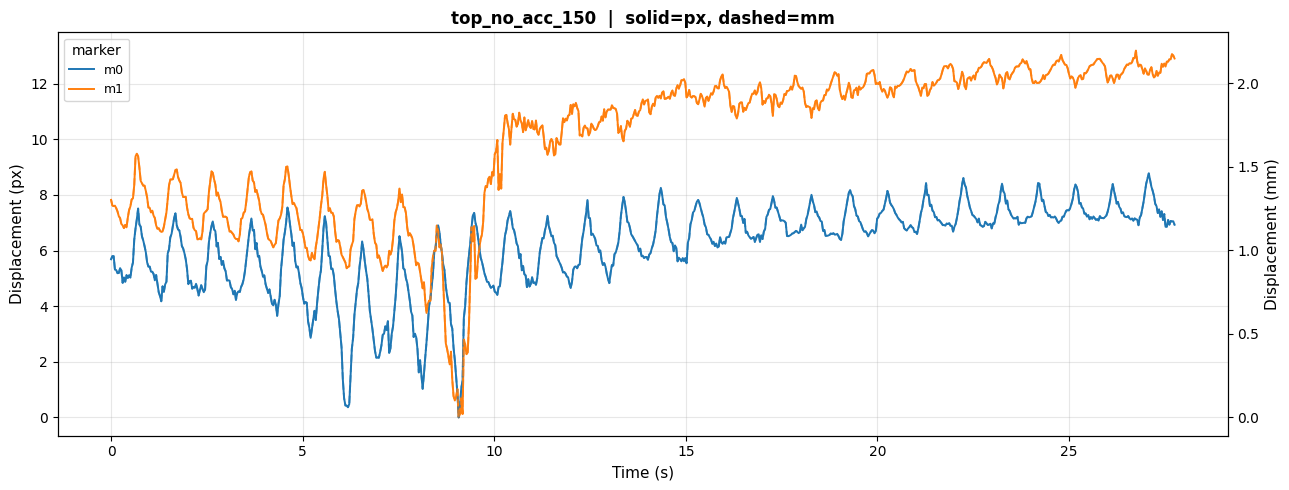

In [25]:
plot_displacement('top_no_acc_150')

[side_no_acc_150] tracking...
  -> 647 frames saved to tracking_viewer/side_no_acc_150_positions.csv


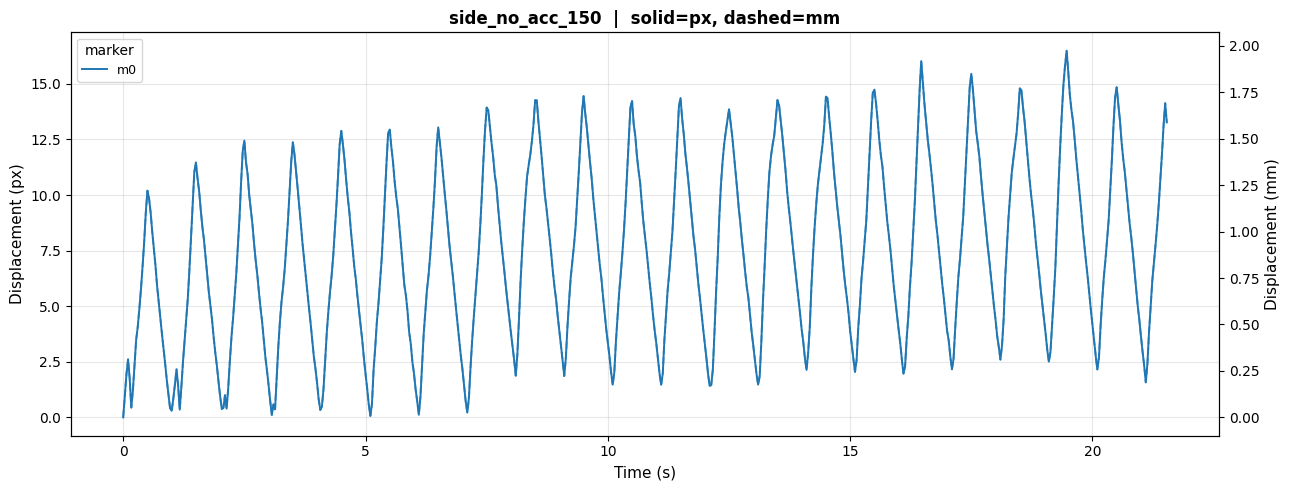

In [5]:
plot_displacement('side_no_acc_150')

[top_with_acc_150] tracking...
  -> 626 frames saved to tracking_viewer/top_with_acc_150_positions.csv


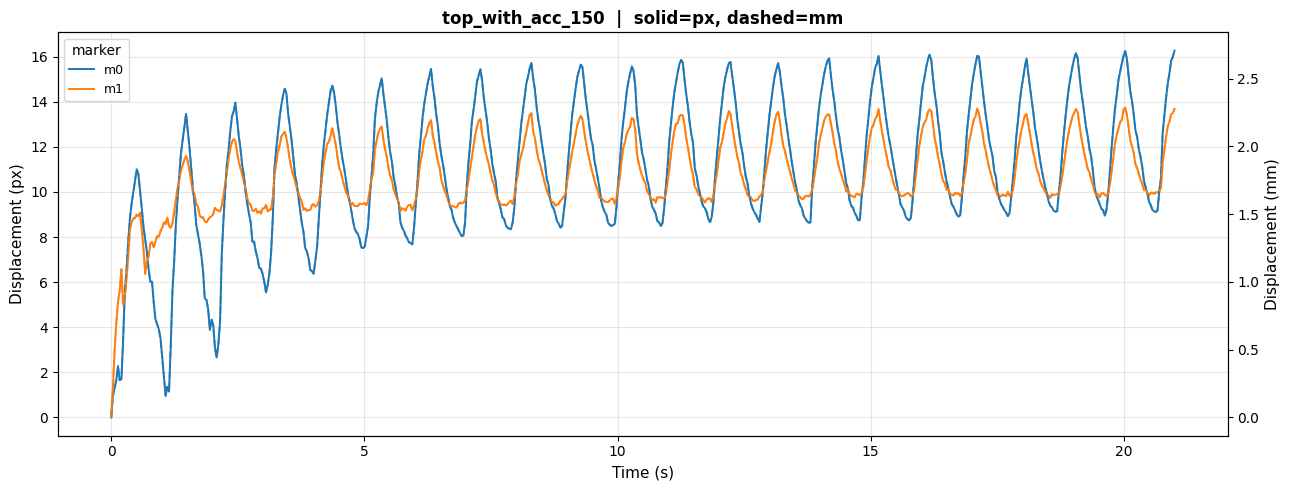

In [16]:
plot_displacement('top_with_acc_150')

[side_with_acc_150] tracking...
  -> 496 frames saved to tracking_viewer/side_with_acc_150_positions.csv


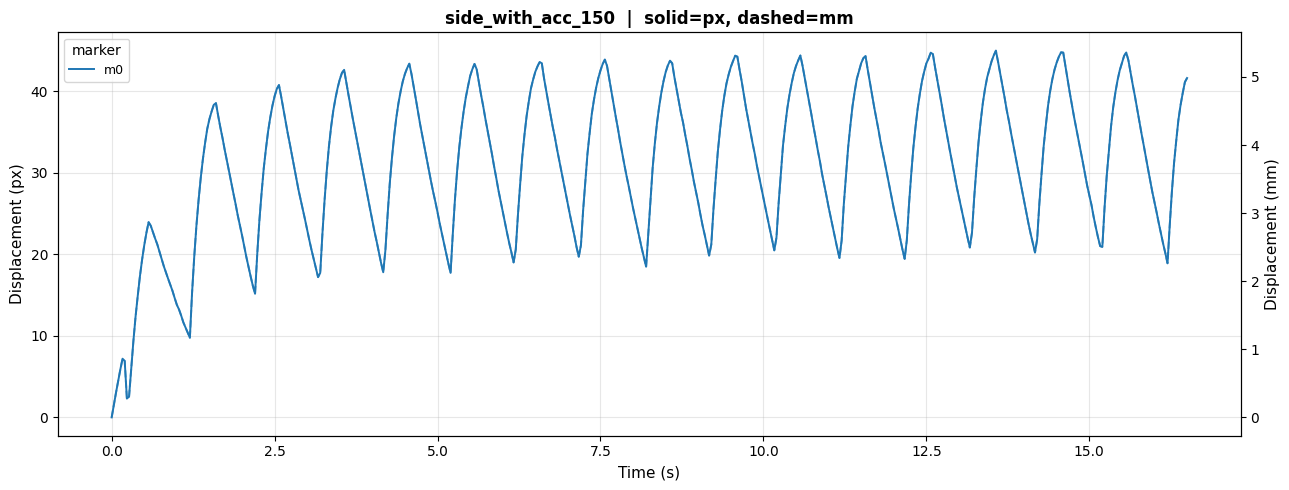

In [6]:
plot_displacement('side_with_acc_150')

## 5. Trimmed / selective graphs

After seeing the full graphs above, fill in your time window and marker selection below.

```python
# Examples:
plot_displacement('top_with_acc_150', t_start=5.0, t_end=10.0)
plot_displacement('top_with_acc_150', markers=[1, 2, 3], t_start=5.0, t_end=10.0)
plot_displacement('side_no_acc_150',  t_start=3.0, t_end=8.0)
plot_displacement('top_no_acc_150',   markers=[1, 2, 3], t_start=4.0, t_end=9.0)

# Add save=True to export a PNG:
plot_displacement('top_with_acc_150', t_start=5.0, t_end=10.0, save=True)
```

[top_with_acc_150] tracking...
  -> 626 frames saved to tracking_viewer/top_with_acc_150_positions.csv


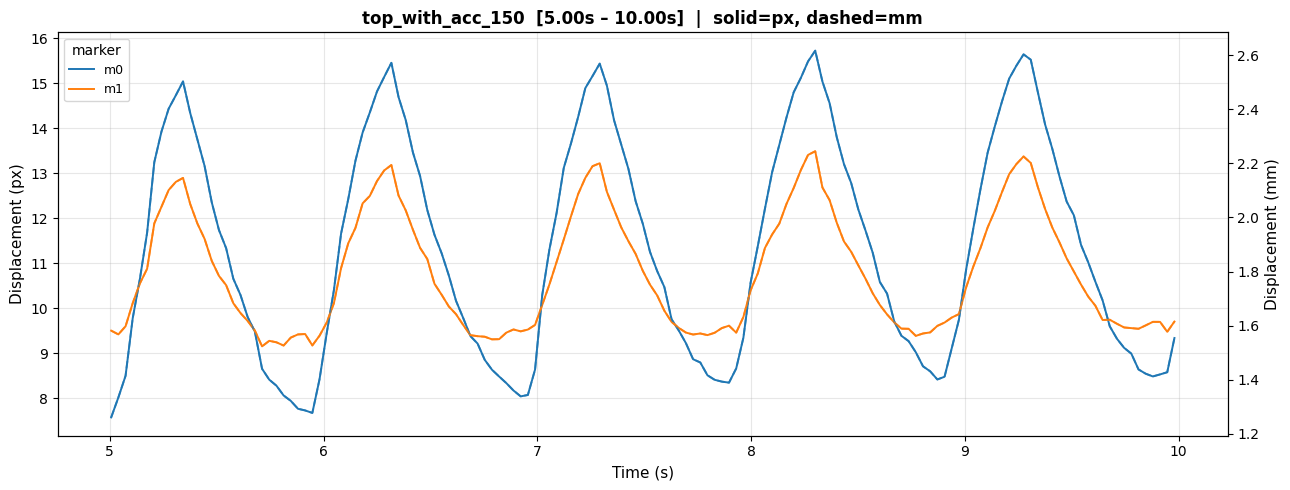

[side_with_acc_150] tracking...
  -> 496 frames saved to tracking_viewer/side_with_acc_150_positions.csv


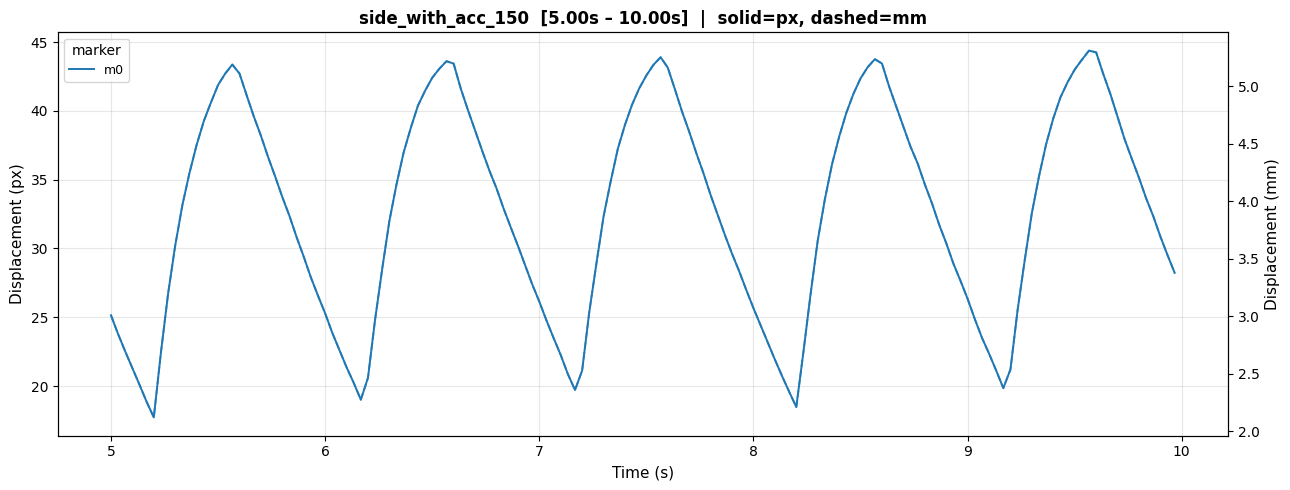

[top_no_acc_150] tracking...
  -> 827 frames saved to tracking_viewer/top_no_acc_150_positions.csv


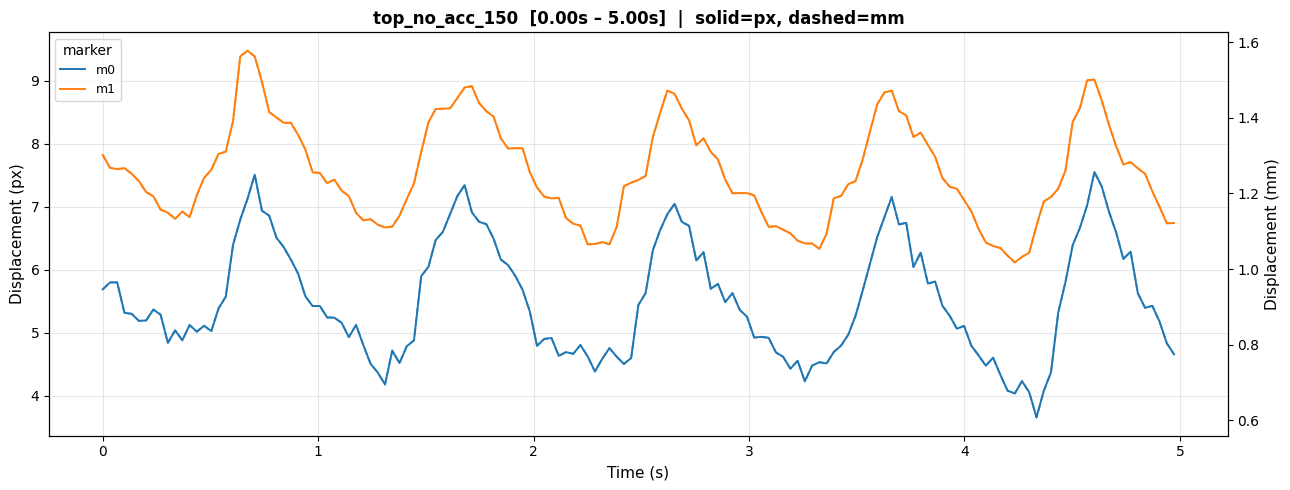

[side_no_acc_150] tracking...
  -> 647 frames saved to tracking_viewer/side_no_acc_150_positions.csv


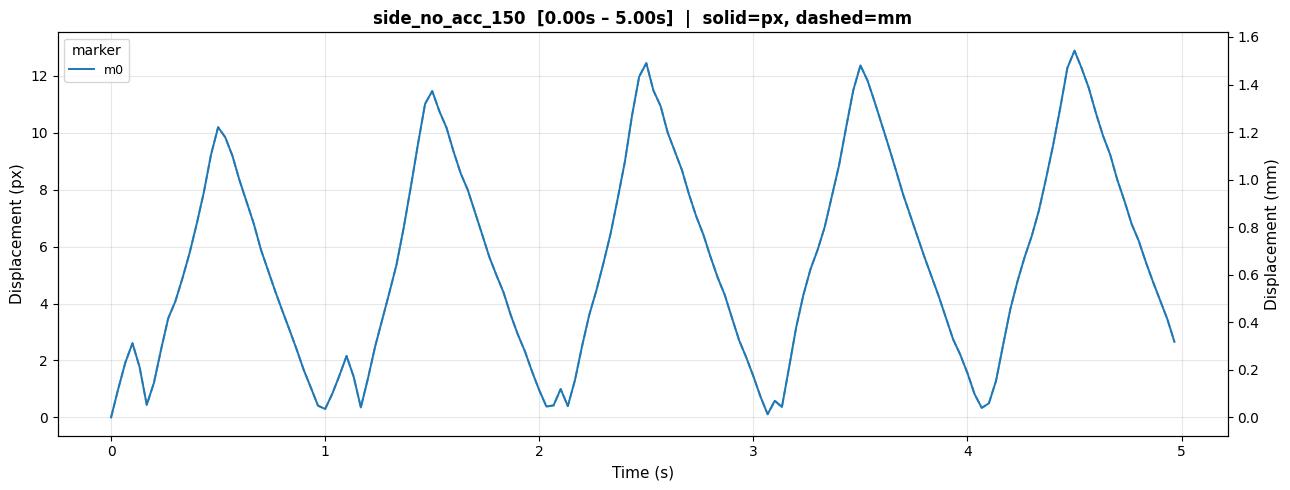

In [34]:
# --- Fill in your parameters and run ---
plot_displacement('top_with_acc_150', t_start=5.0, t_end=10.0)
plot_displacement('side_with_acc_150', t_start=5.0, t_end=10.0)
plot_displacement('top_no_acc_150', t_start=0.0, t_end=5.0)
plot_displacement('side_no_acc_150', t_start=0.0, t_end=5.0)

In [ ]:
# --- Another slot for a second trimmed graph ---
# plot_displacement('side_with_acc_150', t_start=5.0, t_end=10.0)

## 6. Combined graphs

**Step 1**: Use Section 4/5 to find where systole starts in each recording.  
**Step 2**: Set those times as `t_starts` below — this normalizes x=0 to the start of systole.  
**Step 3**: Run the cell. If peaks don't align, nudge `shifts` (e.g. `shifts=[0.0, 0.15]`) until they do.

> First call tracks both videos and caches them. Subsequent calls with different `shifts` reuse the cache — no re-tracking.

[top_with_acc_150] using session cache (re-run helpers cell to force re-track)
[top_no_acc_150] using session cache (re-run helpers cell to force re-track)


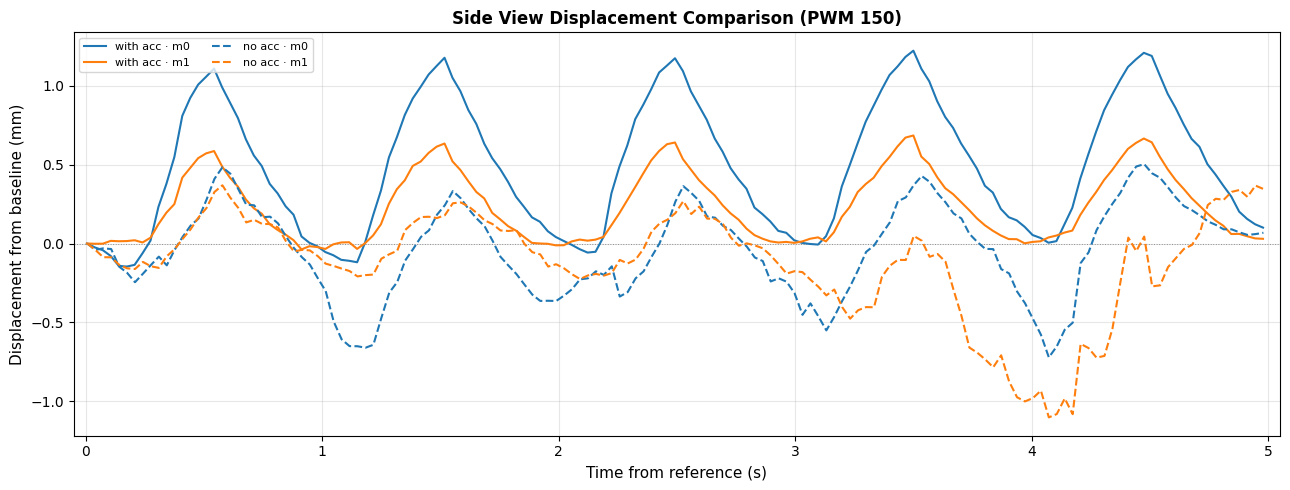

In [44]:
# --- TOP: with_acc vs no_acc ---
# Set t_starts to the timestamp (in each recording) where systole begins.
# Adjust shifts to fine-tune if peaks still don't align after that.
plot_combined(
    video_names = ['top_with_acc_150', 'top_no_acc_150'],
    t_starts    = [4.8, 5.0],    # <-- set these to your systole start times
    shifts      = [0.0, 0.0],    # <-- fine-tune here if needed
    duration    = 5.0,
    markers     = None,          # None = all valid; e.g. [1, 2, 3] to skip m0
    labels      = ['with acc', 'no acc'],
)

[side_with_acc_150] using session cache (re-run helpers cell to force re-track)
[side_no_acc_150] using session cache (re-run helpers cell to force re-track)


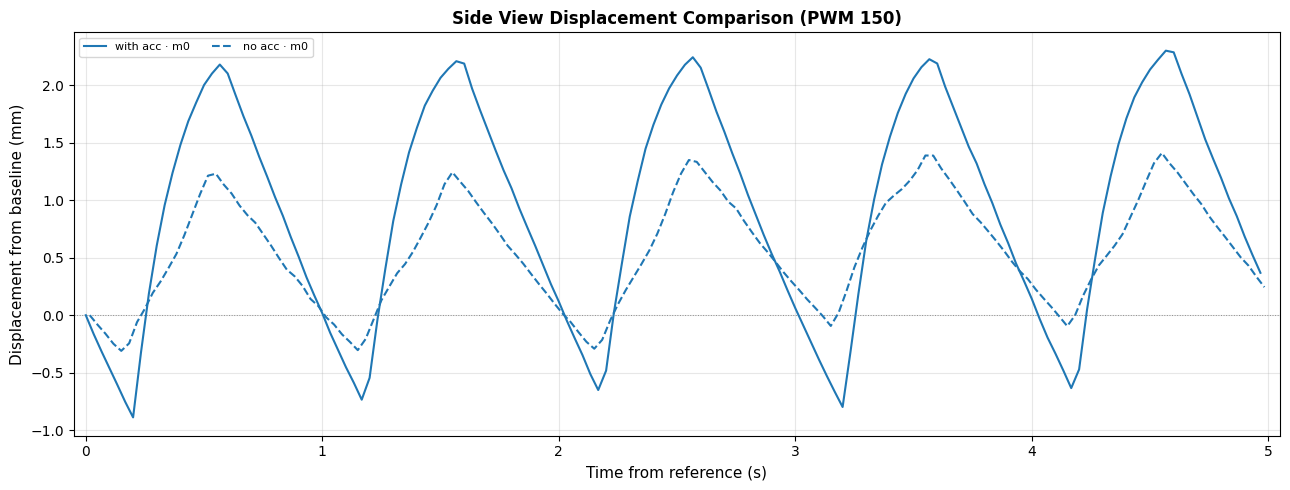

In [43]:
# --- SIDE: with_acc vs no_acc ---
plot_combined(
    video_names = ['side_with_acc_150', 'side_no_acc_150'],
    t_starts    = [5.0, 4.95],    # <-- set these to your systole start times
    shifts      = [0.0, 0.00],    # <-- fine-tune here if needed
    duration    = 5.0,
    markers     = None,
    labels      = ['with acc', 'no acc'],
)